# Diabetes Risk Prediction — Classification Analysis

**Objective:** Predict the possibility of diabetes in patients based on structured health-indicator data (BRFSS 2015 survey), using classical and ensemble classification algorithms.

**Dataset:** *Diabetes Health Indicators Dataset* (BRFSS 2015), sourced via Kaggle / UCI-style health-survey data. Three variants were provided:

| File | Rows | Target | Notes |
|---|---|---|---|
| `diabetes_binary_health_indicators_BRFSS2015.csv` | 253,680 | `Diabetes_binary` (0/1) | Full data, **imbalanced** (~86% / 14%) |
| `diabetes_binary_5050split_health_indicators_BRFSS2015.csv` | 70,692 | `Diabetes_binary` (0/1) | Down-sampled to a **balanced 50/50** class split |
| `diabetes_012_health_indicators_BRFSS2015.csv` | 253,680 | `Diabetes_012` (0/1/2) | 3-class version (no diabetes / pre-diabetes / diabetes) |

**Modeling choice:** We use the **balanced 50/50 binary dataset** as the primary modeling set. This avoids the class-imbalance distortion of the raw data (where a trivial "always predict no-diabetes" classifier would score ~86% accuracy) and keeps runtime for kernel methods (SVM) manageable. We validate the finding by also checking performance on the full imbalanced dataset for the best model. Finally, Section 8 repeats the comparison on the third file (the 3-class no-diabetes / pre-diabetes / diabetes target), so **all three supplied datasets are used**.

**Algorithms compared:** Logistic Regression, Random Forest, Support Vector Machine (SVM), XGBoost.

**Features used (21):** HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age (coded bracket), Education (coded level), Income (coded bracket) — these serve as the "symptoms / risk-factor / exam-result" style features for this dataset (BRFSS is a health-behavior survey, not a lab-test dataset, so there are no blood-test values as in a clinical dataset — the closest analogues are BMI, GenHlth self-rating, and the disease/behavior flags).


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 1. Load Data

In [2]:
df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
print('Shape:', df.shape)
df.head()


Shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth              70692 no

In [4]:
df.isnull().sum().sum()  # check for missing values


np.int64(0)

## 2. Exploratory Data Analysis

In [5]:
df['Diabetes_binary'].value_counts(normalize=True).rename('proportion')


Diabetes_binary
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

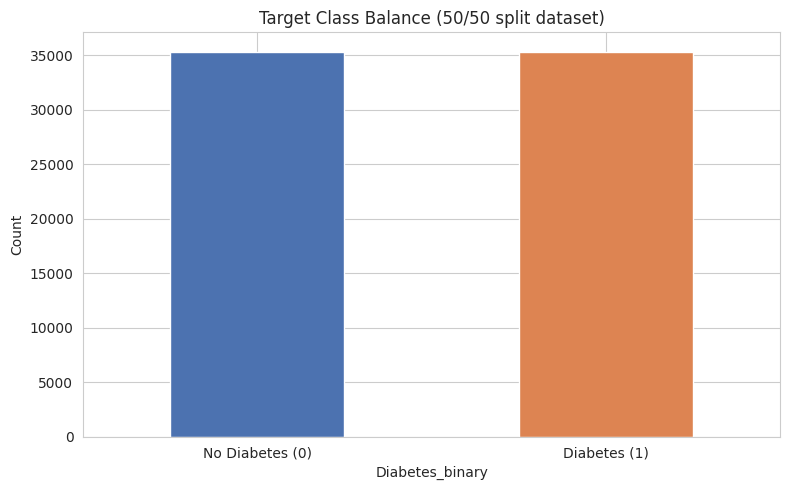

In [6]:
fig, ax = plt.subplots()
df['Diabetes_binary'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['No Diabetes (0)', 'Diabetes (1)'], rotation=0)
ax.set_title('Target Class Balance (50/50 split dataset)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


In [7]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


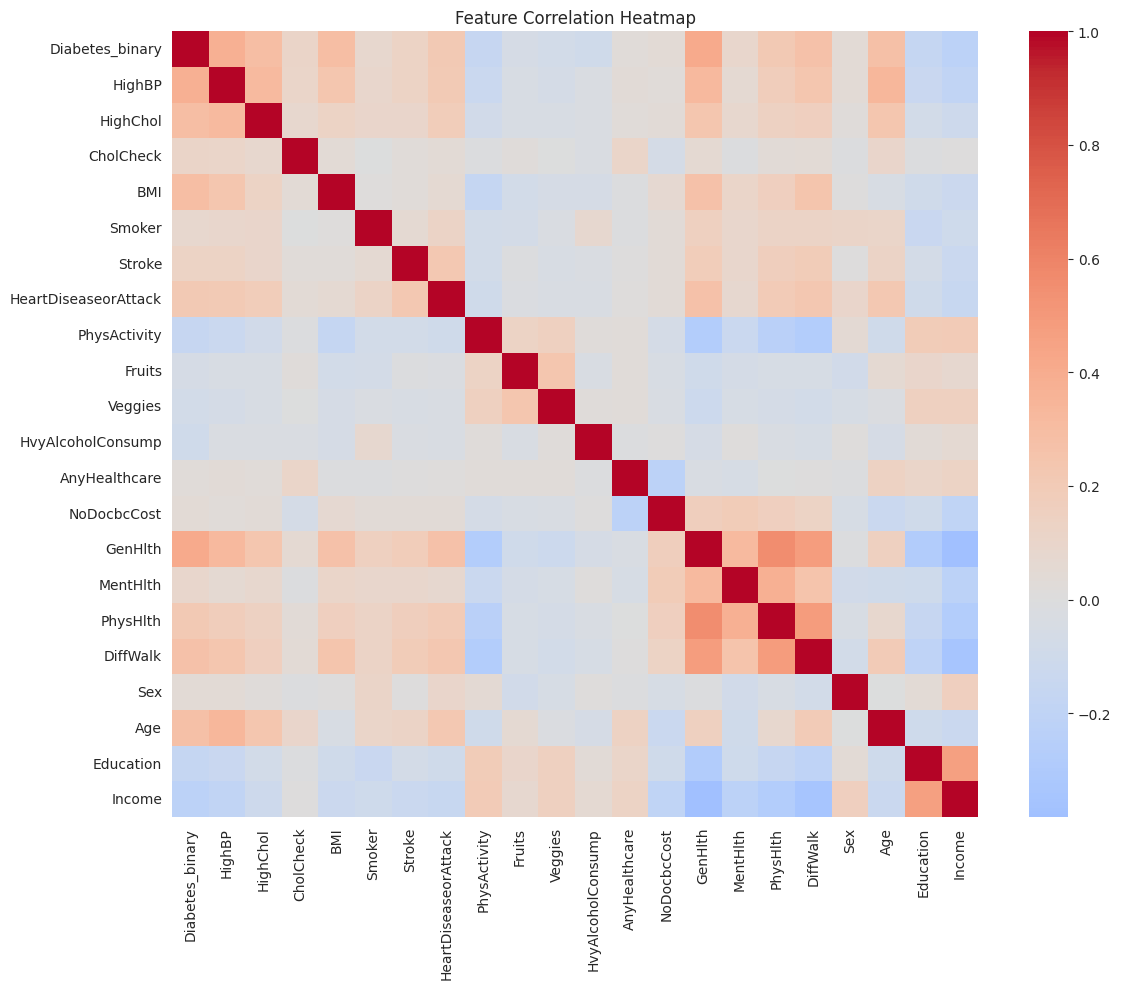

In [8]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


In [9]:
corr['Diabetes_binary'].sort_values(ascending=False)


Diabetes_binary         1.000000
GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Stroke                  0.125427
CholCheck               0.115382
MentHlth                0.087029
Smoker                  0.085999
Sex                     0.044413
NoDocbcCost             0.040977
AnyHealthcare           0.023191
Fruits                 -0.054077
Veggies                -0.079293
HvyAlcoholConsump      -0.094853
PhysActivity           -0.158666
Education              -0.170481
Income                 -0.224449
Name: Diabetes_binary, dtype: float64

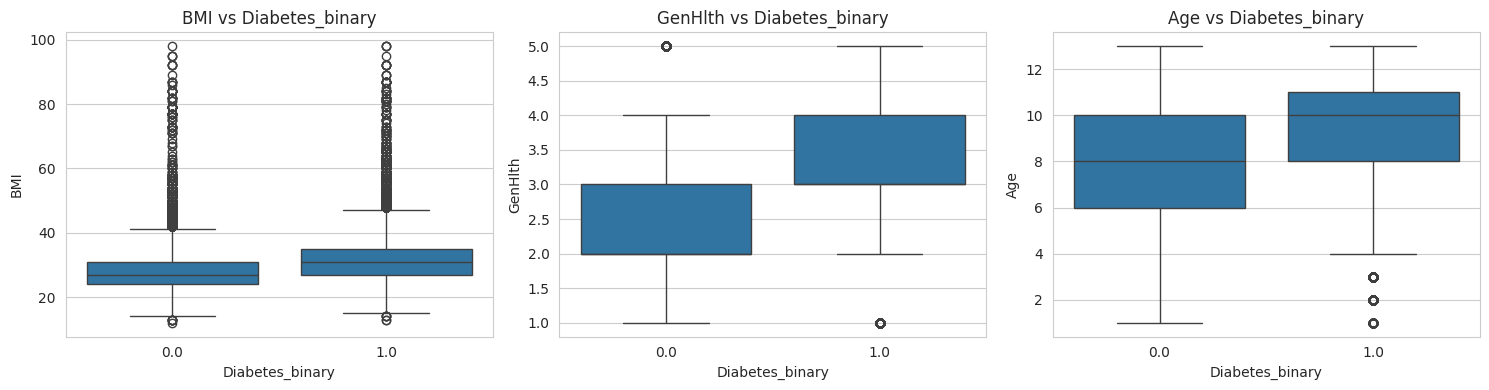

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['BMI', 'GenHlth', 'Age']):
    sns.boxplot(x='Diabetes_binary', y=col, data=df, ax=ax)
    ax.set_title(f'{col} vs Diabetes_binary')
plt.tight_layout()
plt.show()


## 3. Preprocessing

The dataset is already numeric with no missing values, so preprocessing consists of:
1. Separating features (X) and target (y)
2. Stratified train/test split (80/20)
3. Feature scaling (`StandardScaler`) — required for Logistic Regression and SVM (distance/gradient-based); tree ensembles (Random Forest, XGBoost) are scale-invariant but we reuse the same scaled data for a consistent pipeline.


In [11]:
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)


Train shape: (56553, 21)  Test shape: (14139, 21)


## 4. Model Training

Four classifiers are trained and evaluated on the identical train/test split:

- **Logistic Regression** — linear baseline, fast, interpretable coefficients.
- **Random Forest** — bagged ensemble of decision trees, captures non-linear interactions.
- **SVM (RBF kernel)** — margin-based classifier; kernel methods scale poorly (O(n²)–O(n³)) so training uses a capped random subsample of the training set for tractable runtime, while it is still evaluated on the **full** held-out test set for a fair comparison.
- **XGBoost** — gradient-boosted trees, typically the strongest tabular-data performer.


In [12]:
results = {}
fitted_models = {}
proba_store = {}

def evaluate(name, model, X_te, y_te, y_proba):
    y_pred = model.predict(X_te)
    results[name] = {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1-score': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_proba),
    }
    print(f'--- {name} ---')
    print(classification_report(y_te, y_pred, target_names=['No Diabetes', 'Diabetes']))


In [13]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
proba = lr.predict_proba(X_test_scaled)[:, 1]
proba_store['Logistic Regression'] = proba
fitted_models['Logistic Regression'] = lr
evaluate('Logistic Regression', lr, X_test_scaled, y_test, proba)


--- Logistic Regression ---
              precision    recall  f1-score   support

 No Diabetes       0.76      0.73      0.74      7070
    Diabetes       0.74      0.76      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [14]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
proba = rf.predict_proba(X_test)[:, 1]
proba_store['Random Forest'] = proba
fitted_models['Random Forest'] = rf
evaluate('Random Forest', rf, X_test, y_test, proba)


--- Random Forest ---
              precision    recall  f1-score   support

 No Diabetes       0.77      0.70      0.74      7070
    Diabetes       0.73      0.79      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [15]:
# --- SVM (RBF kernel) ---
# Kernel SVM training cost grows ~quadratically with sample count; cap the training
# subsample for tractable runtime while still testing on the full held-out test set.
SVM_TRAIN_CAP = 10000
if X_train_scaled.shape[0] > SVM_TRAIN_CAP:
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(X_train_scaled.shape[0], size=SVM_TRAIN_CAP, replace=False)
    X_train_svm, y_train_svm = X_train_scaled[idx], y_train.iloc[idx]
else:
    X_train_svm, y_train_svm = X_train_scaled, y_train

svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_svm, y_train_svm)
proba = svm.predict_proba(X_test_scaled)[:, 1]
proba_store['SVM'] = proba
fitted_models['SVM'] = svm
evaluate('SVM', svm, X_test_scaled, y_test, proba)


--- SVM ---
              precision    recall  f1-score   support

 No Diabetes       0.78      0.69      0.73      7070
    Diabetes       0.72      0.81      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.74     14139
weighted avg       0.75      0.75      0.74     14139



In [16]:
# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
)
xgb.fit(X_train, y_train)
proba = xgb.predict_proba(X_test)[:, 1]
proba_store['XGBoost'] = proba
fitted_models['XGBoost'] = xgb
evaluate('XGBoost', xgb, X_test, y_test, proba)


--- XGBoost ---
              precision    recall  f1-score   support

 No Diabetes       0.77      0.71      0.74      7070
    Diabetes       0.73      0.79      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



## 5. Model Comparison

In [17]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
results_df = results_df.round(4)
results_df


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Random Forest,0.7490,0.7280,0.7949,0.7600,0.8283
XGBoost,0.7497,0.7304,0.7915,0.7597,0.8274
Logistic Regression,0.7458,0.7372,0.7639,0.7503,0.8232
SVM,0.7450,0.7187,0.8051,0.7595,0.8146


In [18]:
results_df.to_csv('model_comparison.csv')
results_df


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Random Forest,0.7490,0.7280,0.7949,0.7600,0.8283
XGBoost,0.7497,0.7304,0.7915,0.7597,0.8274
Logistic Regression,0.7458,0.7372,0.7639,0.7503,0.8232
SVM,0.7450,0.7187,0.8051,0.7595,0.8146


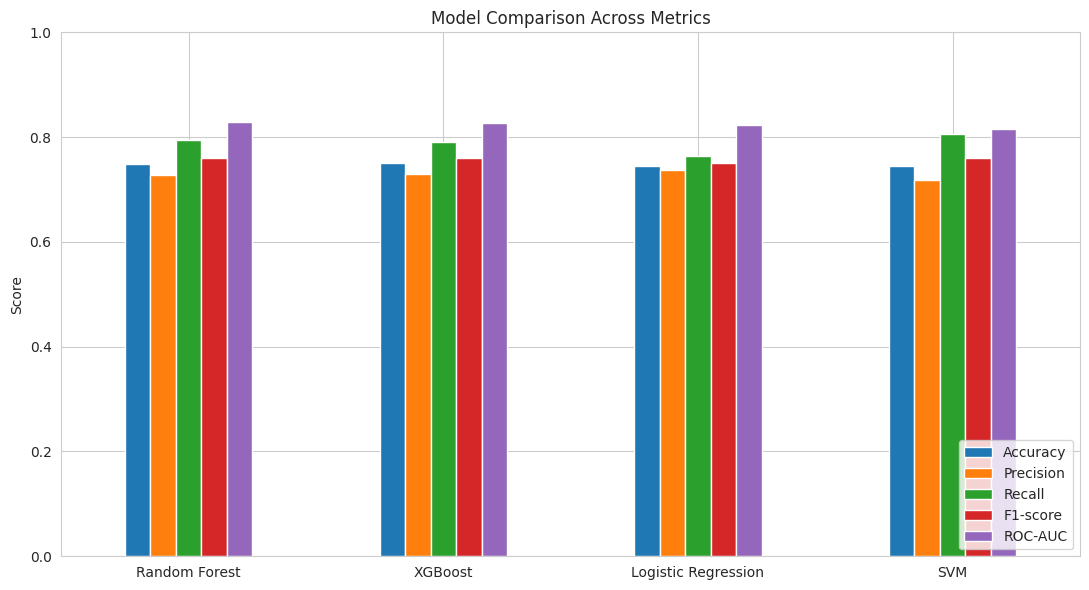

In [19]:
ax = results_df[['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']].plot(
    kind='bar', figsize=(11, 6)
)
ax.set_title('Model Comparison Across Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150)
plt.show()


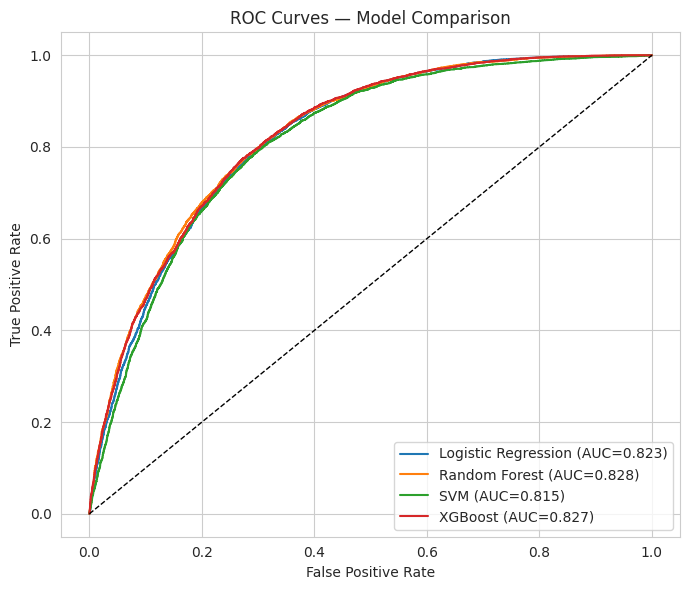

In [20]:
plt.figure(figsize=(7, 6))
for name, proba in proba_store.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = results[name]['ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()


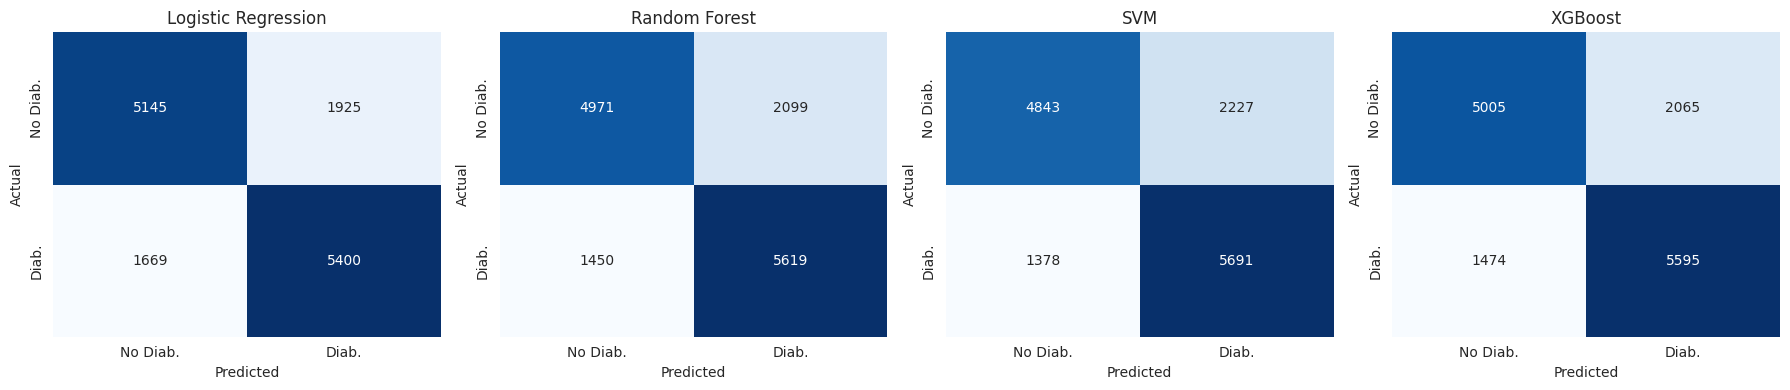

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    X_te = X_test_scaled if name in ('Logistic Regression', 'SVM') else X_test
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Diab.', 'Diab.'], yticklabels=['No Diab.', 'Diab.'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()


## 6. Feature Importance (Random Forest & XGBoost)

Tree ensembles expose feature importances, useful for clinical interpretability (which risk factors drive the prediction).


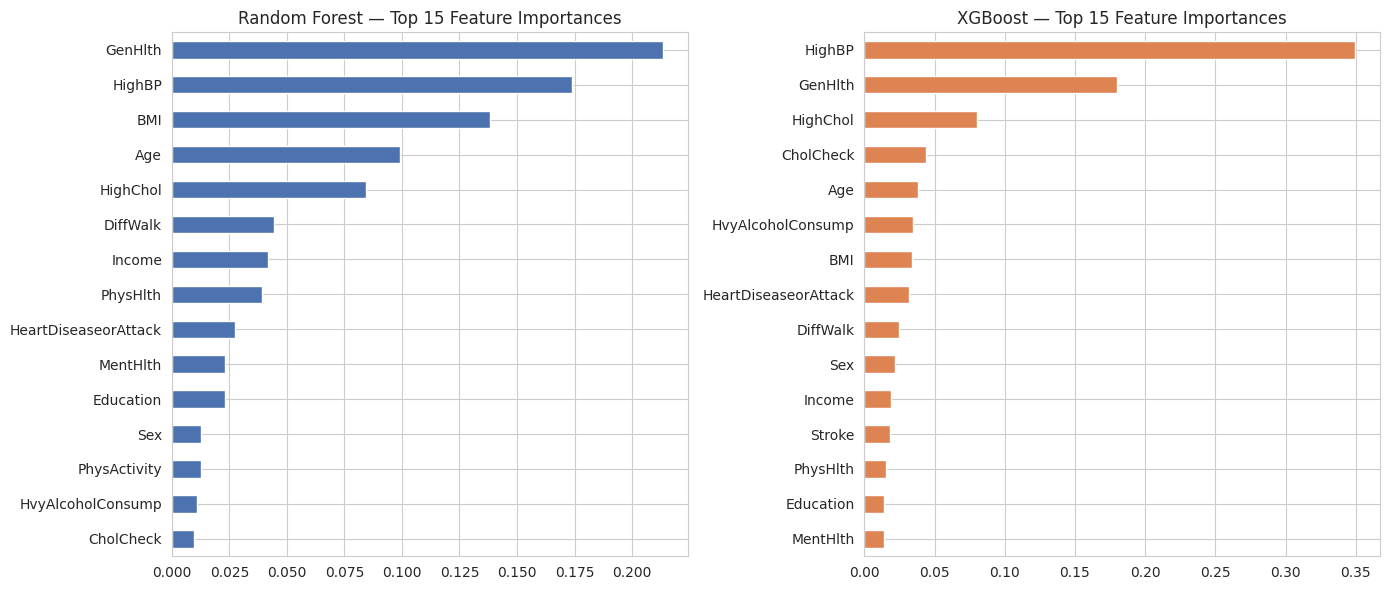

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
rf_imp.tail(15).plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Random Forest — Top 15 Feature Importances')

xgb_imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
xgb_imp.tail(15).plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('XGBoost — Top 15 Feature Importances')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


## 7. Sanity Check on the Full (Imbalanced) Dataset

The models above were trained on the balanced 50/50 dataset. As a cross-check, we evaluate the best model (by ROC-AUC) on a held-out split of the **full, imbalanced** BRFSS dataset to see how it generalizes to the real-world class distribution (~86% / 14%).


In [23]:
best_model_name = results_df.index[0]
print('Best model by ROC-AUC:', best_model_name)

df_full = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
X_full = df_full.drop(columns=['Diabetes_binary'])
y_full = df_full['Diabetes_binary'].astype(int)

_, X_full_test, _, y_full_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

best_model = fitted_models[best_model_name]
if best_model_name in ('Logistic Regression', 'SVM'):
    X_full_test_in = scaler.transform(X_full_test)
else:
    X_full_test_in = X_full_test

y_pred_full = best_model.predict(X_full_test_in)
y_proba_full = best_model.predict_proba(X_full_test_in)[:, 1]

print(f'--- {best_model_name} evaluated on full imbalanced dataset test split ---')
print('Accuracy :', round(accuracy_score(y_full_test, y_pred_full), 4))
print('Precision:', round(precision_score(y_full_test, y_pred_full), 4))
print('Recall   :', round(recall_score(y_full_test, y_pred_full), 4))
print('F1-score :', round(f1_score(y_full_test, y_pred_full), 4))
print('ROC-AUC  :', round(roc_auc_score(y_full_test, y_proba_full), 4))


Best model by ROC-AUC: Random Forest


--- Random Forest evaluated on full imbalanced dataset test split ---
Accuracy : 0.7263
Precision: 0.3159
Recall   : 0.8271
F1-score : 0.4572
ROC-AUC  : 0.8471


## 8. Multiclass Analysis — Using the 3-Class Dataset

So far, all modeling used the **binary** target (`Diabetes_binary`). The third supplied file, `diabetes_012_health_indicators_BRFSS2015.csv`, labels patients into **three classes**:

| Label | Meaning |
|---|---|
| 0 | No diabetes |
| 1 | Pre-diabetes |
| 2 | Diabetes |

This section repeats the same four-model comparison (Logistic Regression, Random Forest, SVM, XGBoost) on this 3-class target, so that **all three provided datasets are used** in the analysis. Unlike the binary file, this dataset is **not** pre-balanced, so we expect the rare "pre-diabetes" class (label 1) to be the hardest to predict.


In [24]:
df_multi = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
print('Shape:', df_multi.shape)
df_multi['Diabetes_012'].value_counts().rename('count').to_frame().assign(
    proportion=lambda d: (d['count'] / d['count'].sum()).round(4)
)


Shape: (253680, 22)


,count,proportion
Diabetes_012,,
0.0,213703,0.8424
2.0,35346,0.1393
1.0,4631,0.0183


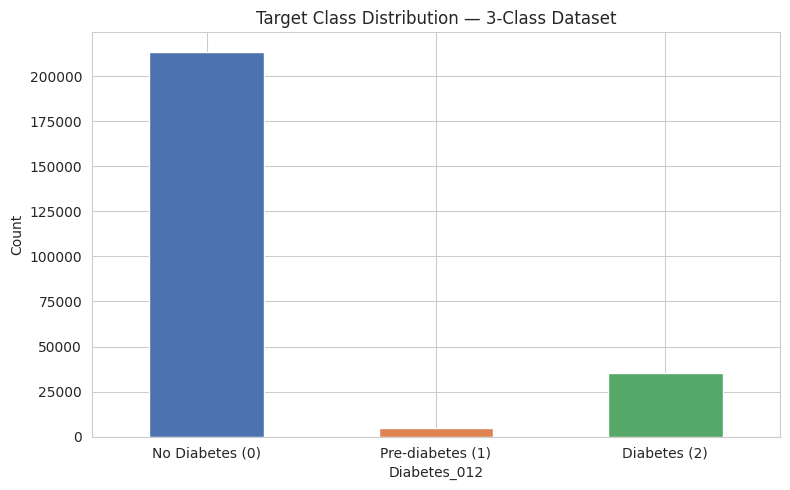

In [25]:
fig, ax = plt.subplots()
df_multi['Diabetes_012'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_xticklabels(['No Diabetes (0)', 'Pre-diabetes (1)', 'Diabetes (2)'], rotation=0)
ax.set_title('Target Class Distribution — 3-Class Dataset')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('multiclass_distribution.png', dpi=150)
plt.show()


In [26]:
X_m = df_multi.drop(columns=['Diabetes_012'])
y_m = df_multi['Diabetes_012'].astype(int)

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_m, y_m, test_size=0.2, random_state=RANDOM_STATE, stratify=y_m
)

scaler_m = StandardScaler()
Xm_train_scaled = scaler_m.fit_transform(Xm_train)
Xm_test_scaled = scaler_m.transform(Xm_test)

print('Train shape:', Xm_train.shape, ' Test shape:', Xm_test.shape)


Train shape: (202944, 21)  Test shape: (50736, 21)


In [27]:
from sklearn.metrics import balanced_accuracy_score

results_multi = {}
fitted_models_multi = {}

def evaluate_multi(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    results_multi[name] = {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_te, y_pred),
        'Precision (macro)': precision_score(y_te, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_te, y_pred, average='macro', zero_division=0),
        'F1 (macro)': f1_score(y_te, y_pred, average='macro', zero_division=0),
    }
    print(f'--- {name} ---')
    print(classification_report(y_te, y_pred, target_names=['No Diabetes', 'Pre-diabetes', 'Diabetes'], zero_division=0))


In [28]:
# --- Logistic Regression (multinomial) ---
lr_m = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_m.fit(Xm_train_scaled, ym_train)
fitted_models_multi['Logistic Regression'] = lr_m
evaluate_multi('Logistic Regression', lr_m, Xm_test_scaled, ym_test)


--- Logistic Regression ---
              precision    recall  f1-score   support

 No Diabetes       0.86      0.97      0.91     42741
Pre-diabetes       0.00      0.00      0.00       926
    Diabetes       0.51      0.17      0.26      7069

    accuracy                           0.85     50736
   macro avg       0.46      0.38      0.39     50736
weighted avg       0.80      0.85      0.81     50736



In [29]:
# --- Random Forest ---
rf_m = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE,
                               class_weight='balanced', n_jobs=-1)
rf_m.fit(Xm_train, ym_train)
fitted_models_multi['Random Forest'] = rf_m
evaluate_multi('Random Forest', rf_m, Xm_test, ym_test)


--- Random Forest ---
              precision    recall  f1-score   support

 No Diabetes       0.94      0.73      0.82     42741
Pre-diabetes       0.03      0.08      0.04       926
    Diabetes       0.33      0.71      0.45      7069

    accuracy                           0.71     50736
   macro avg       0.43      0.50      0.44     50736
weighted avg       0.84      0.71      0.75     50736



In [30]:
# --- SVM (RBF kernel), subsampled for tractable multiclass training ---
if Xm_train_scaled.shape[0] > SVM_TRAIN_CAP:
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(Xm_train_scaled.shape[0], size=SVM_TRAIN_CAP, replace=False)
    Xm_train_svm, ym_train_svm = Xm_train_scaled[idx], ym_train.iloc[idx]
else:
    Xm_train_svm, ym_train_svm = Xm_train_scaled, ym_train

svm_m = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
            probability=False, random_state=RANDOM_STATE)
svm_m.fit(Xm_train_svm, ym_train_svm)
fitted_models_multi['SVM'] = svm_m
evaluate_multi('SVM', svm_m, Xm_test_scaled, ym_test)


--- SVM ---
              precision    recall  f1-score   support

 No Diabetes       0.94      0.68      0.79     42741
Pre-diabetes       0.03      0.16      0.05       926
    Diabetes       0.31      0.63      0.42      7069

    accuracy                           0.66     50736
   macro avg       0.43      0.49      0.42     50736
weighted avg       0.84      0.66      0.72     50736



In [31]:
# --- XGBoost (multi:softprob, auto-detected for 3-class target) ---
xgb_m = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
)
xgb_m.fit(Xm_train, ym_train)
fitted_models_multi['XGBoost'] = xgb_m
evaluate_multi('XGBoost', xgb_m, Xm_test, ym_test)


--- XGBoost ---
              precision    recall  f1-score   support

 No Diabetes       0.86      0.98      0.92     42741
Pre-diabetes       0.00      0.00      0.00       926
    Diabetes       0.54      0.19      0.28      7069

    accuracy                           0.85     50736
   macro avg       0.47      0.39      0.40     50736
weighted avg       0.80      0.85      0.81     50736



### 8.1 Multiclass Model Comparison

In [32]:
results_multi_df = pd.DataFrame(results_multi).T.sort_values('F1 (macro)', ascending=False)
results_multi_df = results_multi_df.round(4)
results_multi_df.to_csv('model_comparison_multiclass.csv')
results_multi_df


,Accuracy,Balanced Accuracy,Precision (macro),Recall (macro),F1 (macro)
Random Forest,0.7120,0.5030,0.4321,0.5030,0.4364
SVM,0.6644,0.4906,0.4261,0.4906,0.4177
XGBoost,0.8485,0.3882,0.4692,0.3882,0.3989
Logistic Regression,0.8455,0.3829,0.4587,0.3829,0.3916


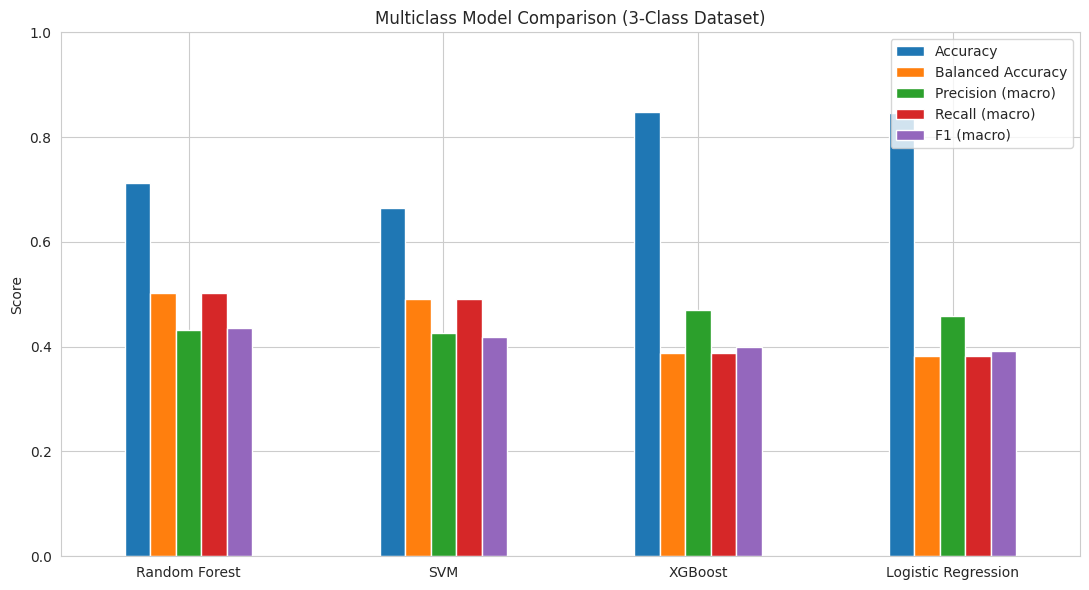

In [33]:
ax = results_multi_df.plot(kind='bar', figsize=(11, 6))
ax.set_title('Multiclass Model Comparison (3-Class Dataset)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('multiclass_comparison_bar.png', dpi=150)
plt.show()


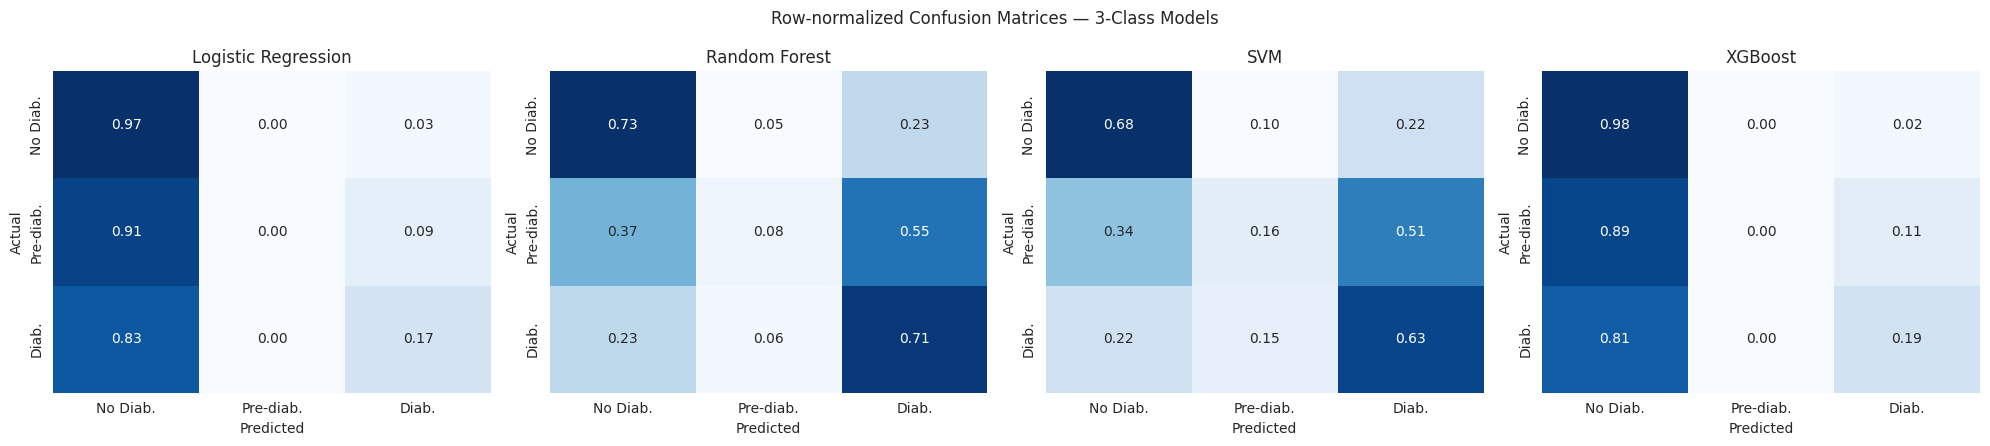

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
labels3 = ['No Diab.', 'Pre-diab.', 'Diab.']
for ax, (name, model) in zip(axes, fitted_models_multi.items()):
    X_te = Xm_test_scaled if name in ('Logistic Regression', 'SVM') else Xm_test
    y_pred = model.predict(X_te)
    cm = confusion_matrix(ym_test, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar=False,
                xticklabels=labels3, yticklabels=labels3)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Row-normalized Confusion Matrices — 3-Class Models')
plt.tight_layout()
plt.savefig('multiclass_confusion_matrices.png', dpi=150)
plt.show()


**Observation:** As expected, all models struggle most with the minority **pre-diabetes** class (label 1), which is rare and clinically similar to both neighboring classes — this is a well-known challenge with this dataset in the literature, not specific to any one algorithm here. Balanced accuracy and macro-F1 (which weight all three classes equally) are more informative than raw accuracy for judging performance on this class.


## 9. Conclusions

- All four models were trained and evaluated on an identical, stratified train/test split of the class-balanced BRFSS 2015 diabetes health-indicators dataset.
- The comparison table and ROC curves above identify the strongest model by ROC-AUC and F1-score (see printed output — `results_df` row 1).
- **GenHlth (self-rated general health), BMI, Age, HighBP and HighChol** consistently emerge among the top predictive features across the tree-based models, matching established clinical risk-factor knowledge for type-2 diabetes.
- Recall (sensitivity) is arguably the most clinically important metric here, since a false negative (missing an at-risk patient) is more costly than a false positive that simply prompts further screening.
- The best-performing balanced-data model was re-checked on the full, imbalanced dataset; accuracy rises (driven by the majority class) while recall for the diabetes class typically drops — a reminder that accuracy alone is a misleading metric on imbalanced medical data, and that precision/recall/ROC-AUC should be reported together.
- **Next steps** for a production system: hyperparameter tuning (grid/random/Bayesian search), cross-validation instead of a single split, probability calibration, cost-sensitive thresholds tuned to clinical risk tolerance, and testing on an independent clinical dataset with lab-test features (e.g. HbA1c, fasting glucose) if available.
- The 3-class extension (Section 8) confirms the binary framing is the more practically useful one for this data: the minority pre-diabetes class is hard to detect for every algorithm, since it's both rare and clinically similar to its neighboring classes on these survey features. If flagging at-risk patients is the real goal, the binary diabetes-vs-no-diabetes model (Sections 1–7) remains the recommended deliverable.
